# Figure 2. Comparison of standard TRK and SD-TRK (relatively well-conditioned)

Reproduces Figure 2 (§5.1.3) of *A Spectrally Damped Tensor Randomized
Kaczmarz Method for Doubly Noisy Tensor Systems*.

- **(a) Experiment 5.1.3** — standard TRK (`Fig2a.eps`)
- **(b) Experiment 5.1.3** — SD-TRK (`Fig2b.eps`)

**Common setting.** Dimensions $(n_1,n_2,n_3,n_4)=(20,10,5,5)$ with the asymmetric noise
configuration $\delta_A=10^{-3}$, $\delta_B=0.5$: right-hand-side perturbations are emphasized
while structural distortion of the system tensor stays mild. Data are generated as

$$\tilde{\mathcal{A}}=\mathcal{A}+\delta_A\,\mathcal{G}_A,\qquad \tilde{\mathcal{B}}=\mathcal{A}\mathcal{X}^\star+\delta_B\,\mathcal{G}_B,$$

with the entries of $\mathcal{A},\mathcal{X}^\star,\mathcal{G}_A,\mathcal{G}_B$ i.i.d. standard Gaussian.
Both algorithms start from $\mathcal{X}^0=\mathbf{0}$ and run $T=2000$ iterations; all curves are
averaged over $20$ independent Monte Carlo trials. Three quantities are tracked:
the least-squares error $\|\mathcal{X}^t-\mathcal{X}^{LS}\|_F$ with
$\operatorname{unfold}(\mathcal{X}^{LS})=\operatorname{bcirc}(\tilde{\mathcal{A}})^\dagger\operatorname{unfold}(\tilde{\mathcal{B}})$,
the true error $\|\mathcal{X}^t-\mathcal{X}^\star\|_F$, and the observable residual
$\|\tilde{\mathcal{A}}\mathcal{X}^t-\tilde{\mathcal{B}}\|_F$.

**SD-TRK** uses $\omega=0.9$ and the slice-dependent damping rule

$$\lambda^{(k)}=\lambda_{\mathrm{floor}}+\lambda_{\mathrm{scale}}\,(\delta_A^2+\delta_B^2)\,\frac{\|\hat{\tilde{A}}^{(k)}\|_F^2}{n_1},\qquad k=1,\ldots,n_3,\qquad \lambda_{\mathrm{scale}}=5.0,\ \lambda_{\mathrm{floor}}=10^{-6}.$$

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.size': 14,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'ps.fonttype': 42,
})

In [17]:
def t_prod(A, B):
    # t-product: FFT along mode 3 -> slice-wise matmul -> inverse FFT (Appendix A)
    n1, _, n3 = A.shape
    n4 = B.shape[1]
    A_hat = np.fft.fft(A, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    C_hat = np.zeros((n1, n4, n3), dtype=complex)
    for k in range(n3):
        C_hat[:, :, k] = A_hat[:, :, k] @ B_hat[:, :, k]
    return np.fft.ifft(C_hat, axis=2).real


def t_transpose(A):
    # conjugate transpose: transpose each frontal slice, then reverse slices 2..n3
    n1, n2, n3 = A.shape
    At = np.zeros((n2, n1, n3), dtype=A.dtype)
    At[:, :, 0] = A[:, :, 0].T
    for k in range(1, n3):
        At[:, :, k] = A[:, :, n3 - k].T
    return At


def t_inv(tube):
    # tube inverse: reciprocal per Fourier frequency (nonzero by Assumption 2.9)
    hat = np.fft.fft(tube, axis=2)
    return np.fft.ifft(1.0 / hat, axis=2).real


def tnorm(T):
    # Frobenius norm of a tensor
    return np.linalg.norm(T.reshape(-1))


def trk_step(X, Aslice, Bslice):
    # standard TRK update: X <- X + A_i^* (A_i A_i^*)^{-1} (B_i - A_i X)
    resid = Bslice - t_prod(Aslice, X)
    At = t_transpose(Aslice)
    scale = t_inv(t_prod(Aslice, At))
    return X + t_prod(At, t_prod(scale, resid))


def sdtrk_step(X, Aslice, Bslice, lambdas, omega):
    # SD-TRK update, slice-wise in the Fourier domain (Algorithm 1):
    # X^(k) <- X^(k) - omega * a^* (a a^* + lambda_k)^{-1} (a X^(k) - b)
    A_hat = np.fft.fft(Aslice, axis=2)
    B_hat = np.fft.fft(Bslice, axis=2)
    X_hat = np.fft.fft(X, axis=2)
    for k in range(X.shape[2]):
        a = A_hat[0, :, k][None, :]  # row slice -> a a^* is a scalar
        resid = a @ X_hat[:, :, k] - B_hat[0, :, k][None, :]
        denom = np.linalg.norm(a)**2 + lambdas[k]
        X_hat[:, :, k] -= omega * (a.conj().T / denom) @ resid
    return np.fft.ifft(X_hat, axis=2).real

In [18]:
n1, n2, n3, n4 = 20, 10, 5, 5
delta_A, delta_B = 1e-3, 0.5   # mild operator noise, substantial observation noise
T = 2000
trials = 20
omega = 0.9
lambda_scale, lambda_floor = 5.0, 1e-6


def make_data(rng):
    # doubly noisy data: A~ = A + delta_A*G_A, B~ = A*X* + delta_B*G_B
    Atrue = rng.standard_normal((n1, n2, n3))
    Xstar = rng.standard_normal((n2, n4, n3))
    Btrue = t_prod(Atrue, Xstar)
    Aobs = Atrue + delta_A * rng.standard_normal((n1, n2, n3))
    Bobs = Btrue + delta_B * rng.standard_normal((n1, n4, n3))
    return Xstar, Aobs, Bobs


def ls_target(Aobs, Bobs):
    # least-squares benchmark: unfold(X_LS) = bcirc(A~)^+ unfold(B~), slice-wise in Fourier
    A_hat = np.fft.fft(Aobs, axis=2)
    B_hat = np.fft.fft(Bobs, axis=2)
    X_hat = np.zeros((n2, n4, n3), dtype=complex)
    for k in range(n3):
        X_hat[:, :, k] = np.linalg.lstsq(A_hat[:, :, k], B_hat[:, :, k], rcond=None)[0]
    return np.fft.ifft(X_hat, axis=2).real


def lambda_rule(Aobs):
    # slice-dependent damping: lambda_k = floor + scale*(dA^2 + dB^2)*||A_hat^(k)||_F^2 / n1
    A_hat = np.fft.fft(Aobs, axis=2)
    slicesq = np.array([np.linalg.norm(A_hat[:, :, k])**2 for k in range(n3)])
    return lambda_floor + lambda_scale * (delta_A**2 + delta_B**2) * slicesq / n1


def run_trials(method, seed=7):
    # average the three metrics over independent Monte Carlo trials
    master = np.random.default_rng(seed)
    curves = {'ls': [], 'true': [], 'resid': []}
    for _ in range(trials):
        rng = np.random.default_rng(int(master.integers(0, 2**32 - 1)))
        Xstar, Aobs, Bobs = make_data(rng)
        Xls = ls_target(Aobs, Bobs)
        lambdas = lambda_rule(Aobs)
        rowsq = np.array([tnorm(Aobs[i:i+1])**2 for i in range(n1)])
        prob = rowsq / rowsq.sum()
        X = np.zeros((n2, n4, n3))
        hls, htrue, hres = [], [], []
        for t in range(T):
            i = int(rng.choice(n1, p=prob))
            if method == 'sdtrk':
                X = sdtrk_step(X, Aobs[i:i+1], Bobs[i:i+1], lambdas, omega)
            else:
                X = trk_step(X, Aobs[i:i+1], Bobs[i:i+1])
            hls.append(tnorm(X - Xls))
            htrue.append(tnorm(X - Xstar))
            hres.append(tnorm(t_prod(Aobs, X) - Bobs))
        curves['ls'].append(hls)
        curves['true'].append(htrue)
        curves['resid'].append(hres)
    return {key: np.mean(vals, axis=0) for key, vals in curves.items()}


def plot_metrics(curves, fname):
    lo = 0.8 * min(c.min() for c in curves.values())
    hi = 1.2 * max(c.max() for c in curves.values())
    plt.figure(figsize=(6, 4))
    plt.semilogy(curves['ls'], color='black', linewidth=1.5,
                 label=r'$\|\mathcal{X}^t - \mathcal{X}^{LS}\|_F$')
    plt.semilogy(curves['true'], color='black', marker='o', markerfacecolor='white',
                 markevery=T // 12, markersize=2.5, linewidth=1.5,
                 label=r'$\|\mathcal{X}^t - \mathcal{X}^\star\|_F$')
    plt.semilogy(curves['resid'], color='black', linestyle='--', linewidth=1.5,
                 label=r'$\|\tilde{\mathcal{A}} \mathcal{X}^t - \tilde{\mathcal{B}}\|_F$')
    plt.xlabel(r'Iteration $t$')
    plt.ylim(lo, hi)
    plt.gca().yaxis.set_minor_locator(mticker.NullLocator())
    plt.legend(frameon=False, handlelength=1.4, labelspacing=0.25, borderpad=0.2)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

### (a) Experiment 5.1.3 — Standard TRK

**Expected result.** Final least-squares error $0.8755$, true error $1.4214$, residual $11.7462$.
The observable residual plateaus after roughly $150$–$200$ iterations while the true error keeps
decreasing and stays separated from the residual trajectory — residual-based stopping criteria
are therefore hard to calibrate for standard TRK in this noisy setting.

final error to X_LS   = 0.8755
final error to X_star = 1.4214
final residual        = 11.7462


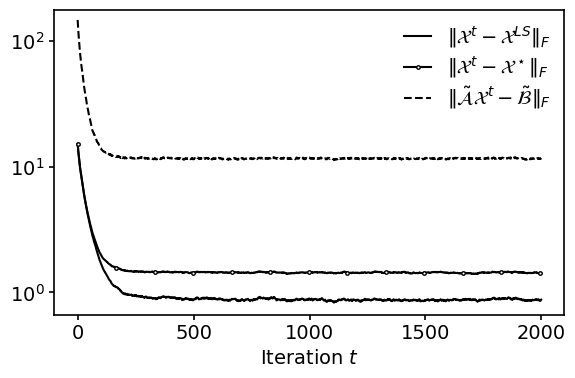

In [19]:
trk = run_trials('trk')

print(f"final error to X_LS   = {trk['ls'][-1]:.4f}")
print(f"final error to X_star = {trk['true'][-1]:.4f}")
print(f"final residual        = {trk['resid'][-1]:.4f}")
plot_metrics(trk, 'Fig2a.eps')

### (b) Experiment 5.1.3 — SD-TRK

**Expected result.** Final least-squares error $0.4017$, true error $1.2020$, residual $8.8521$ —
lower than standard TRK on all three metrics. Moreover, the residual trajectory and the true
error stabilize at approximately the same iteration stage, so the observable residual is a more
informative convergence diagnostic for SD-TRK than for standard TRK.

final error to X_LS   = 0.4017
final error to X_star = 1.2020
final residual        = 8.8521


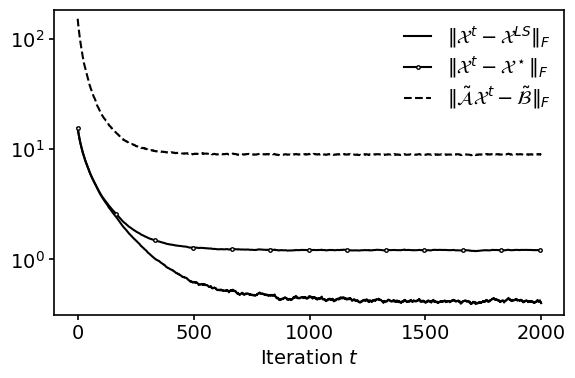

In [20]:
sdtrk = run_trials('sdtrk')

print(f"final error to X_LS   = {sdtrk['ls'][-1]:.4f}")
print(f"final error to X_star = {sdtrk['true'][-1]:.4f}")
print(f"final residual        = {sdtrk['resid'][-1]:.4f}")
plot_metrics(sdtrk, 'Fig2b.eps')